In [9]:
import pandas as pd

df = pd.read_csv(
    'shoporders.csv',
    sep=',',
    encoding='utf-8',
    decimal='.',
    parse_dates=['order_date']
)

df

,order_id,customer_name,product,category,quantity,unit,price,currency,order_date,shipping_country,payment_method
0,1150,Markus Frei,Aktenordner,Büro,1,Stück,9.41,CHF,2024-07-18,Schweiz,Kreditkarte
1,1002,Stefan Wagner,Laptop,Elektro,1,Stück,813.87,CHF,2024-08-02,Italien,Twint
2,1158,Nicole Gerber,Springseil,Sport,4,Stück,16.23,CHF,2024-07-05,Deutschland,PayPal
3,1052,Laura Zimmermann,Trinkflasche,Sport,4,Stück,21.09,CHF,2024-04-22,NaN,Twint
4,1138,Julia Fischer,Laufschuhe,Sport,5,Stück,120.10,CHF,2024-04-02,Switzerlaand,Rechnung
...,...,...,...,...,...,...,...,...,...,...,...
207,1034,Thomas Bauer,Tablet,Elektro,5,Stück,408.63,CHF,2024-03-24,Deutschland,Twint
208,1117,Michael Braun,Taschenrechner,Büro,5,Stück,19.32,EUR,2024-01-27,Frankreich,Rechnung
209,1015,Lukas Brunner,Drucker,Büro,1,Stück,272.80,CHF,2024-03-06,Deutschland,Twint
210,1030,Monika Lehmann,Smartphone,Elektro,3,Stück,807.51,EUR,2024-04-17,Italien,Rechnung


In [10]:
# 1. Ausreisser im Preis erkennen und entfernen (IQR-Methode)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
(df['price'] < ug) |
(df['price'] > og)
]
print(f'Ausreisser: {len(ausreisser)}')

df_clean = df[(df['price'] >= ug) & (df['price'] <= og)].copy()
print(f"Anzahl Zeilen vor Ausreisser-Entfernung: {len(df)}")
print(f"Anzahl Zeilen nach Ausreisser-Entfernung: {len(df_clean)}\n")


Ausreisser: 26
Anzahl Zeilen vor Ausreisser-Entfernung: 212
Anzahl Zeilen nach Ausreisser-Entfernung: 182



In [11]:
# 2. Lagemasse und Streumasse für die Preisspalte berechnen
print("Lagemasse")
print(f"Mittelwert (Mean): {df_clean['price'].mean():.2f} CHF")
print(f"Median: {df_clean['price'].median():.2f} CHF")
print(f"Modus: {df_clean['price'].mode()[0]:.2f} CHF")

print("Streumasse")
print(f"Standardabweichung: {df_clean['price'].std():.2f}")
print(f"Varianz: {df_clean['price'].var():.2f}")
print(f"Spannweite: {df_clean['price'].max() - df_clean['price'].min():.2f} CHF")

Lagemasse
Mittelwert (Mean): 60.44 CHF
Median: 44.61 CHF
Modus: 21.30 CHF
Streumasse
Standardabweichung: 59.00
Varianz: 3481.01
Spannweite: 265.17 CHF


In [12]:
# 3. Korrelation zwischen numerischen Spalten finden
num_cols = df_clean.select_dtypes(include=['number'])
print(num_cols.corr())

          order_id  quantity     price
order_id  1.000000 -0.098475 -0.086708
quantity -0.098475  1.000000 -0.025196
price    -0.086708 -0.025196  1.000000


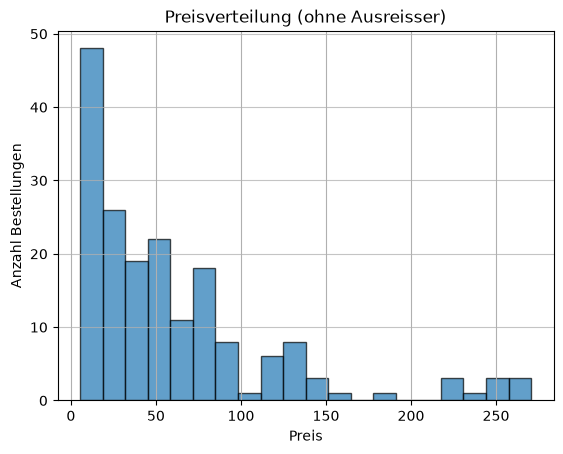

In [ ]:
# 4. Histogramm der Preisverteilung
import matplotlib.pyplot as plt
df_clean['price'].hist(bins=20, edgecolor='black', alpha=0.7)
plt.title('Preisverteilung (ohne Ausreisser)')
plt.xlabel('Preis')
plt.ylabel('Anzahl Bestellungen')
plt.grid(axis='y', alpha=0.75)
plt.show()

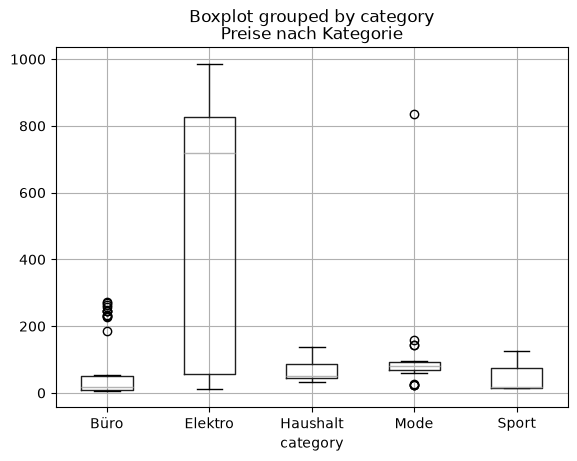

In [15]:
# 4. Boxplot der Preisverteilung
df.boxplot(column='price', by='category')
plt.title('Preise nach Kategorie')
plt.show()

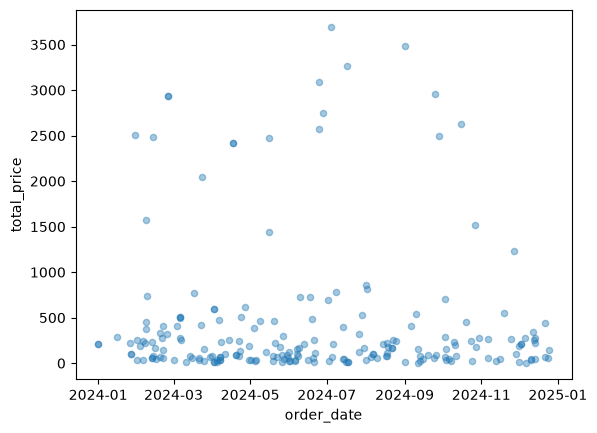

In [17]:
# 5. Streudiagramm: total_price über die Zeit
df['total_price'] = df['price'] * df['quantity']
df.plot.scatter(x='order_date', y='total_price', alpha=0.4)
plt.show()